In [ ]:
# 0. 나눔고딕 폰트 설치 및 필요한 모델 install
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

!pip install catboost shap

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (17.3 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and direct

In [ ]:
# 0. 필요한 라이브러리 import 및 폰트 설정하기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns
import shap
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.metrics import roc_curve, auc

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
mpl.rc('font', family='NanumGothic')
mpl.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
shap.initjs() # SHAP 자바스크립트 시각화 활성화

## 1. 예측 성능 확인 및 시각화 함수 생성

In [ ]:
# 세 가지 모델을 동일한 기준으로 공정하게 채점하기 위한 통합 성능 측정 함수입니다. 뒤에서 같은 거 3번 쓰는 것보다 함수로 만들면 편할 거 같아 이렇게 해보았습니다.
def evaluate_model(y_true, y_pred, y_proba, model_name, city_name):
    print(f"\n{city_name} {model_name} 모델 결과")

    # 1차적인 성능 지표로서 정확도, 불균형 데이터에 중요한 F1-Score, 모델의 분류 성능인 ROC-AUC 값이 나오며,
    # 이후 긍정과 부정별로 정밀도와 재현율을 볼 수 있도록 하고,
    # 모델이 어떤 걸 맞추고 틀렸는지 볼 수 있는 Confusion Matrix를 그려보았습니다.

    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_proba):.4f}")

    print("\n[정밀도와 재현율]")
    print(classification_report(y_true, y_pred, target_names=['긍정(0)', '부정(1)']))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=['예측: 긍정', '예측: 부정'],
                yticklabels=['실제: 긍정', '실제: 부정'])
    plt.title(f'{city_name} {model_name} Confusion Matrix')
    plt.ylabel('실제 라벨')
    plt.xlabel('예측 라벨')
    plt.show()

## 1. 깃에서 데이터 가져오기 및 데이터 분할 작업

In [ ]:
# 3개 도시의 원본 리뷰 데이터와 32차원으로 압축된 임베딩 데이터(pca)의 URL을 깃에서 가져와서 분석을 수행하였습니다.
# 우리의 타겟이 감정이기에 is_positive를 타겟으로 설정하고, 리뷰 데이터와 임베딩 데이터를 읽어왔습니다.
# 불만족 요인을 분석하기 위해서 불만족 리뷰를 에측 타겟(1)으로 재설정하였습니다.
# 이후 stratify 옵션을 사용하고 Train/Test를 분할하였습니다. (랜덤스테이트 혹시 변경하실거면 하셔도 됩니다. 우선 42로 두겠습니다.)

github_urls = {
    "New Orleans": {
        "raw_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/data/processed/yelp_subset_new_orleans_15k_features.csv",
        "pca_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/text_embedding/new_orleans_pca_32.csv"
    },
    "Philly": {
        "raw_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/data/processed/yelp_subset_philly_15k_features.csv",
        "pca_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/text_embedding/philly_pca_32.csv"
    },
    "Tucson": {
        "raw_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/data/processed/yelp_subset_tucson_15k_features.csv",
        "pca_url": "https://raw.githubusercontent.com/2026-1st/Team-6/main/text_embedding/tucson_pca_32.csv"
    }
}

target_col = 'is_positive'
city_datasets = {}
global_results = {city: {} for city in github_urls.keys()}

for city, urls in github_urls.items():
    df_raw = pd.read_csv(urls["raw_url"])
    df_pca = pd.read_csv(urls["pca_url"])

    df_pca['target_label'] = 1 - df_raw[target_col].values

    X = df_pca.drop(columns=['target_label'])
    y = df_pca['target_label']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    city_datasets[city] = (X_train, X_test, y_train, y_test)
    print(f"{city}의 결과 (Train: {X_train.shape[0]}건, Test: {X_test.shape[0]}건)")

New Orleans의 결과 (Train: 12000건, Test: 3000건)
Philly의 결과 (Train: 12000건, Test: 3000건)
Tucson의 결과 (Train: 12000건, Test: 3000건)


## 2. 딥러닝 모델 구조 정의

In [ ]:
# PyTorch를 활용하여 딥러닝 모델의 아키텍처와 학습 함수를 정의하였습니다.
# 32차원으로 압축된 임베딩 데이터를 입력받아서 긍정/부정 확률을 출력하도록 3개의 층으로 구성하였고,
# 데이터의 클래스 불균형, 즉 불만족 리뷰가 너무 적거나 하는 등의 현상을 해결하기 위해서 불만족 리뷰를 놓쳤을 때 더 큰 가중치를 부여하도록 하는 비용 민감 학습인 BCEWithLogitsLoss를 적용하였습니다.
# 모델 학습이 끝나면 정의한 평가 함수를 호출하고, 추후 시각화를 위해 예측 확률을 저장하도록 하였습니다.

# 데이터셋 클래스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class ReviewDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# 다층 퍼셉트론(MLP) 신경망 아키텍처
class MLP(nn.Module):
    def __init__(self, input_dim=32):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

# 딥러닝 학습 및 평가를 위한 통합 함수
def train_and_evaluate_dl(city, X_train, X_test, y_train, y_test, epochs=30):
    train_loader = DataLoader(ReviewDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(ReviewDataset(X_test, y_test), batch_size=64, shuffle=False)
    model = MLP(input_dim=32).to(device)

    # 이부분이 데이터 불균형을 맞추기 위해 가중치를 계산해서 부여한 부분입니다.
    num_neg, num_pos = sum(y_train == 0), sum(y_train == 1)
    pos_weight_val = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    model.train()
    for epoch in range(epochs):
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    all_preds, all_probs = [], []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            probs = torch.sigmoid(model(batch_X.to(device)))
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend((probs >= 0.5).float().cpu().numpy())

    preds_flat = np.array(all_preds).flatten()
    probs_flat = np.array(all_probs).flatten()

    evaluate_model(y_test, preds_flat, probs_flat, "PyTorch MLP", city)
    global_results[city]['dl_proba'] = probs_flat

## 3. 3가지 모델 예측 수행


New Orleans Logistic Regression 모델 결과
Accuracy : 0.9323
F1-Score : 0.8367
ROC-AUC  : 0.9853

[정밀도와 재현율]
              precision    recall  f1-score   support

       긍정(0)       0.99      0.93      0.96      2451
       부정(1)       0.75      0.95      0.84       549

    accuracy                           0.93      3000
   macro avg       0.87      0.94      0.90      3000
weighted avg       0.94      0.93      0.94      3000



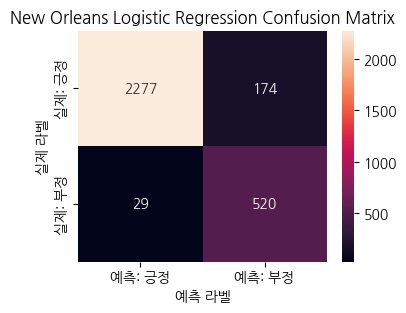


New Orleans CatBoost 모델 결과
Accuracy : 0.9447
F1-Score : 0.8551
ROC-AUC  : 0.9835

[정밀도와 재현율]
              precision    recall  f1-score   support

       긍정(0)       0.98      0.96      0.97      2451
       부정(1)       0.82      0.89      0.86       549

    accuracy                           0.94      3000
   macro avg       0.90      0.92      0.91      3000
weighted avg       0.95      0.94      0.95      3000



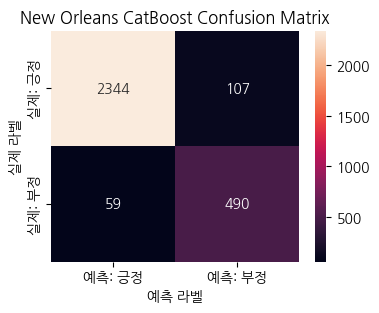


New Orleans PyTorch MLP 모델 결과
Accuracy : 0.9293
F1-Score : 0.8323
ROC-AUC  : 0.9861

[정밀도와 재현율]
              precision    recall  f1-score   support

       긍정(0)       0.99      0.92      0.96      2451
       부정(1)       0.74      0.96      0.83       549

    accuracy                           0.93      3000
   macro avg       0.86      0.94      0.89      3000
weighted avg       0.94      0.93      0.93      3000



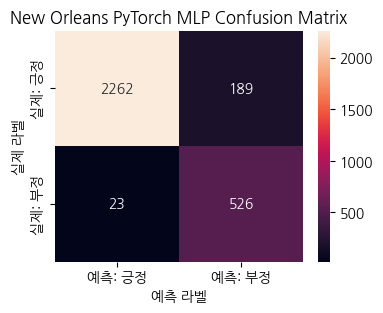

In [ ]:
# 앞서 분할한 데이터 중 먼저 뉴올리언스 지역의 데이터를 바탕으로 세 가지 모델의 학습 및 평가를 진행하였습니다.
# 학습이 끝난 후, 각 모델의 예측 확률값과 CatBoost 모델 객체는 최종 비교 시각화 및 SHAP 분석을 위해 딕셔너리에 저장하였습니다.

city = "New Orleans"
X_train, X_test, y_train, y_test = city_datasets[city]

# 1. 로지스틱 회귀
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, lr_preds, lr_proba, "Logistic Regression", city)
global_results[city]['lr_proba'] = lr_proba

# 2. CatBoost
num_neg, num_pos = sum(y_train == 0), sum(y_train == 1)
cb_model = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                              scale_pos_weight=(num_neg/num_pos),
                              eval_metric='AUC', random_seed=42, verbose=0)
cb_model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)
cb_preds = cb_model.predict(X_test)
cb_proba = cb_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, cb_preds, cb_proba, "CatBoost", city)
global_results[city]['cb_model'] = cb_model
global_results[city]['cb_proba'] = cb_proba

# 3. PyTorch MLP
train_and_evaluate_dl(city, X_train, X_test, y_train, y_test, epochs=30)


Philly Logistic Regression 모델 결과
Accuracy : 0.9327
F1-Score : 0.8543
ROC-AUC  : 0.9837

[정밀도와 재현율]
              precision    recall  f1-score   support

       긍정(0)       0.99      0.93      0.96      2376
       부정(1)       0.78      0.95      0.85       624

    accuracy                           0.93      3000
   macro avg       0.88      0.94      0.91      3000
weighted avg       0.94      0.93      0.94      3000



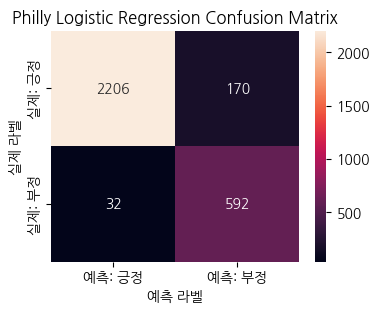


Philly CatBoost 모델 결과
Accuracy : 0.9367
F1-Score : 0.8580
ROC-AUC  : 0.9830

[정밀도와 재현율]
              precision    recall  f1-score   support

       긍정(0)       0.98      0.94      0.96      2376
       부정(1)       0.80      0.92      0.86       624

    accuracy                           0.94      3000
   macro avg       0.89      0.93      0.91      3000
weighted avg       0.94      0.94      0.94      3000



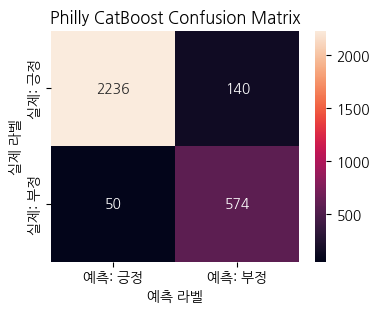


Philly PyTorch MLP 모델 결과
Accuracy : 0.9273
F1-Score : 0.8460
ROC-AUC  : 0.9844

[정밀도와 재현율]
              precision    recall  f1-score   support

       긍정(0)       0.99      0.92      0.95      2376
       부정(1)       0.76      0.96      0.85       624

    accuracy                           0.93      3000
   macro avg       0.87      0.94      0.90      3000
weighted avg       0.94      0.93      0.93      3000



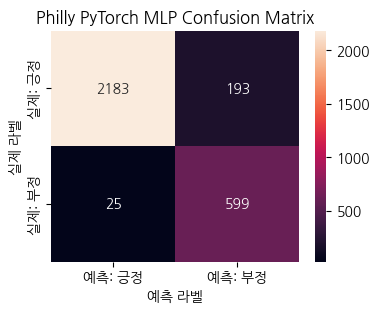

In [ ]:
# 필라델피아 지역

city = "Philly"
X_train, X_test, y_train, y_test = city_datasets[city]

# 1. 로지스틱 회귀
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, lr_preds, lr_proba, "Logistic Regression", city)
global_results[city]['lr_proba'] = lr_proba

# 2. CatBoost
num_neg, num_pos = sum(y_train == 0), sum(y_train == 1)
cb_model = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                              scale_pos_weight=(num_neg/num_pos),
                              eval_metric='AUC', random_seed=42, verbose=0)
cb_model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)
cb_preds = cb_model.predict(X_test)
cb_proba = cb_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, cb_preds, cb_proba, "CatBoost", city)
global_results[city]['cb_model'] = cb_model
global_results[city]['cb_proba'] = cb_proba

# 3. PyTorch MLP
train_and_evaluate_dl(city, X_train, X_test, y_train, y_test, epochs=30)


Tucson Logistic Regression 모델 결과
Accuracy : 0.9433
F1-Score : 0.8952
ROC-AUC  : 0.9876

[정밀도와 재현율]
              precision    recall  f1-score   support

       긍정(0)       0.98      0.94      0.96      2234
       부정(1)       0.85      0.95      0.90       766

    accuracy                           0.94      3000
   macro avg       0.91      0.94      0.93      3000
weighted avg       0.95      0.94      0.94      3000



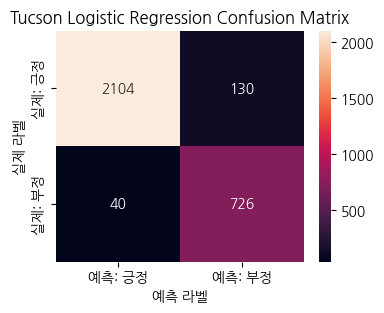


Tucson CatBoost 모델 결과
Accuracy : 0.9447
F1-Score : 0.8957
ROC-AUC  : 0.9864

[정밀도와 재현율]
              precision    recall  f1-score   support

       긍정(0)       0.98      0.95      0.96      2234
       부정(1)       0.86      0.93      0.90       766

    accuracy                           0.94      3000
   macro avg       0.92      0.94      0.93      3000
weighted avg       0.95      0.94      0.95      3000



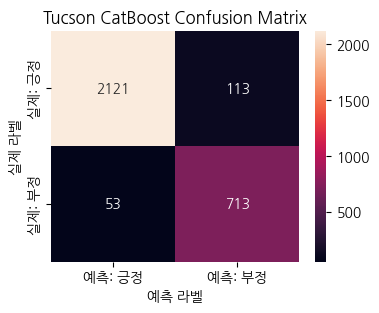


Tucson PyTorch MLP 모델 결과
Accuracy : 0.9423
F1-Score : 0.8935
ROC-AUC  : 0.9870

[정밀도와 재현율]
              precision    recall  f1-score   support

       긍정(0)       0.98      0.94      0.96      2234
       부정(1)       0.85      0.95      0.89       766

    accuracy                           0.94      3000
   macro avg       0.91      0.94      0.93      3000
weighted avg       0.95      0.94      0.94      3000



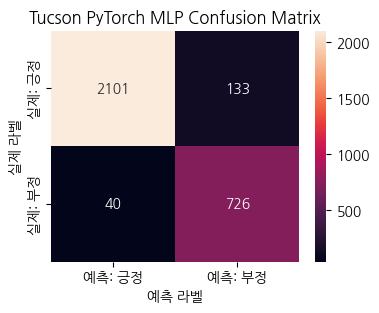

In [ ]:
# 투손 지역

city = "Tucson"
X_train, X_test, y_train, y_test = city_datasets[city]

# 1. 로지스틱 회귀
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, lr_preds, lr_proba, "Logistic Regression", city)
global_results[city]['lr_proba'] = lr_proba

# 2. CatBoost
num_neg, num_pos = sum(y_train == 0), sum(y_train == 1)
cb_model = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                              scale_pos_weight=(num_neg/num_pos),
                              eval_metric='AUC', random_seed=42, verbose=0)
cb_model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)
cb_preds = cb_model.predict(X_test)
cb_proba = cb_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, cb_preds, cb_proba, "CatBoost", city)
global_results[city]['cb_model'] = cb_model
global_results[city]['cb_proba'] = cb_proba

# 3. PyTorch MLP
train_and_evaluate_dl(city, X_train, X_test, y_train, y_test, epochs=30)

## 4. 결과 시각화 및 해석

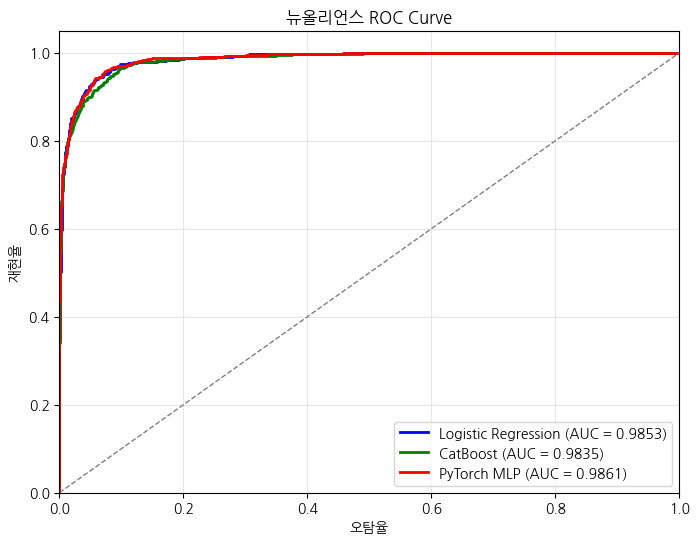

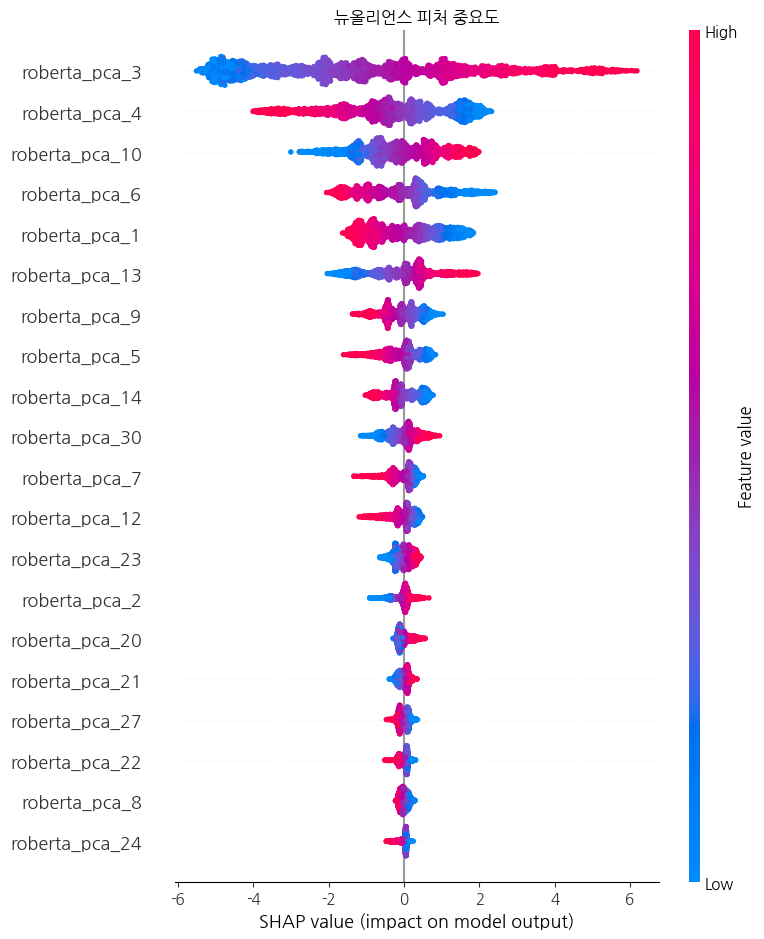

<Figure size 800x500 with 0 Axes>

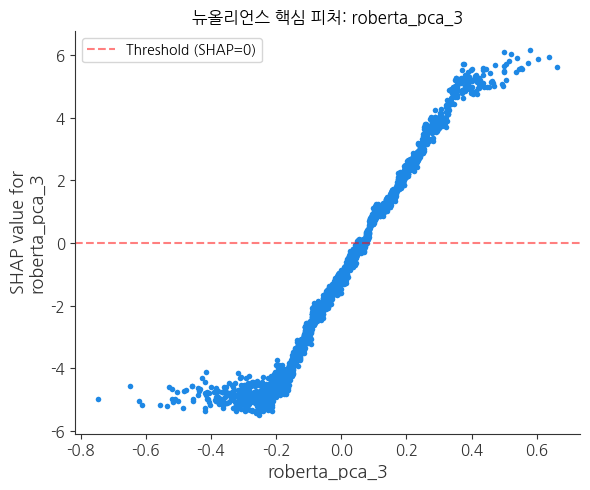

In [ ]:
# 앞서 저장해둔 예측 결과와 모델 객체를 바탕으로 뉴올리언스 지역의 시각화 리포트를 생성하였습니다.
# 세 모델의 성능을 비교하는 ROC Curve, 핵심 요인을 분석하는 SHAP Summary Plot 및 Dependence Plot을 시각화하였습니다.
# 마지막으로 전체 데이터의 SHAP 값을 군집화(Clustering)하는 Heatmap Plot을 추가하여, 개별 리뷰가 아닌 '전체 고객의 불만 유형(Macro Pattern)'이 어떻게 세분화되는지 거시적인 마케팅 인사이트를 도출하였습니다.

city = "New Orleans"

X_train, X_test, y_train, y_test = city_datasets[city]
lr_probs = global_results[city]['lr_proba']
cb_probs = global_results[city]['cb_proba']
dl_probs = global_results[city]['dl_proba']

# 다중 모델 ROC Curve
plt.figure(figsize=(8, 6))
for name, probs, color in [("Logistic Regression", lr_probs, 'blue'),
                           ("CatBoost", cb_probs, 'green'),
                           ("PyTorch MLP", dl_probs, 'red')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('오탐율')
plt.ylabel('재현율')
plt.title('뉴올리언스 ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("뉴올리언스 피처 중요도")
plt.tight_layout()
plt.show()

# SHAP Dependence Plot
top_feature_idx = np.argmax(np.abs(shap_values).mean(axis=0))
top_feature_name = X_test.columns[top_feature_idx]

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature_idx, shap_values, X_test, interaction_index=None, show=False)
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Threshold (SHAP=0)')
plt.title(f"뉴올리언스 핵심 피처: {top_feature_name}")
plt.legend()
plt.tight_layout()
plt.show()

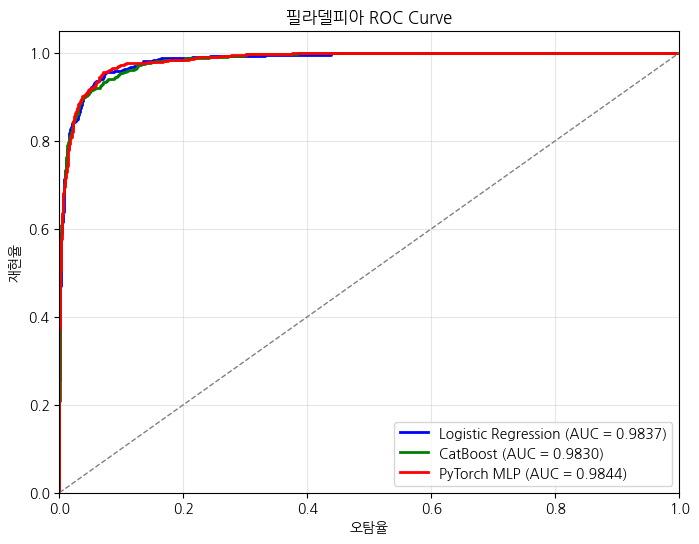

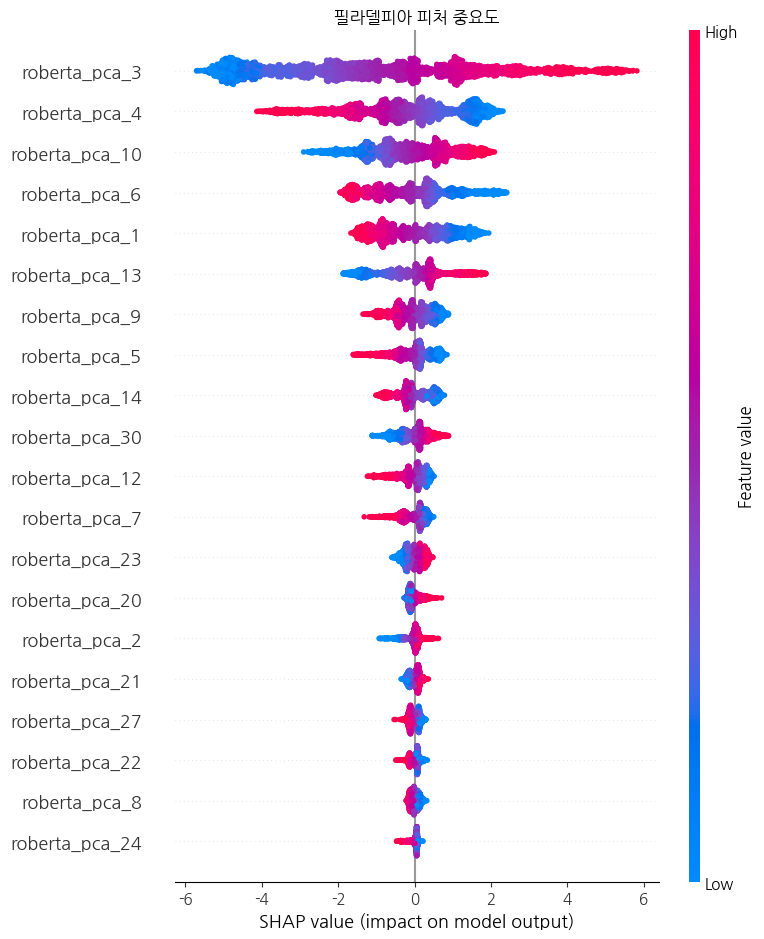

<Figure size 800x500 with 0 Axes>

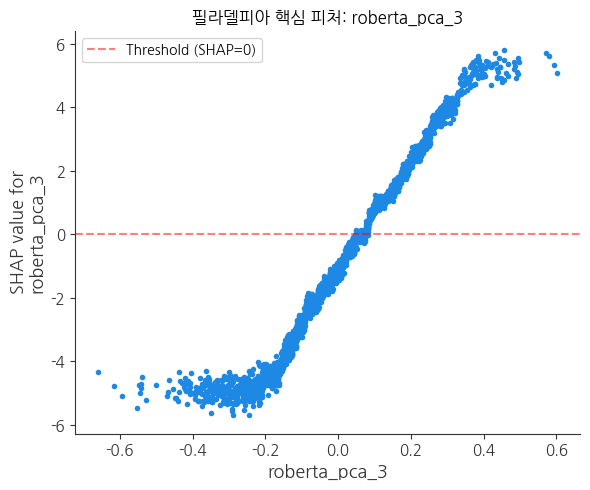

In [ ]:
# 필라델피아입니다.

city = "Philly"

X_train, X_test, y_train, y_test = city_datasets[city]
lr_probs = global_results[city]['lr_proba']
cb_probs = global_results[city]['cb_proba']
dl_probs = global_results[city]['dl_proba']

# 다중 모델 ROC Curve
plt.figure(figsize=(8, 6))
for name, probs, color in [("Logistic Regression", lr_probs, 'blue'),
                           ("CatBoost", cb_probs, 'green'),
                           ("PyTorch MLP", dl_probs, 'red')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('오탐율')
plt.ylabel('재현율')
plt.title('필라델피아 ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("필라델피아 피처 중요도")
plt.tight_layout()
plt.show()

# SHAP Dependence Plot
top_feature_idx = np.argmax(np.abs(shap_values).mean(axis=0))
top_feature_name = X_test.columns[top_feature_idx]

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature_idx, shap_values, X_test, interaction_index=None, show=False)
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Threshold (SHAP=0)')
plt.title(f"필라델피아 핵심 피처: {top_feature_name}")
plt.legend()
plt.tight_layout()
plt.show()


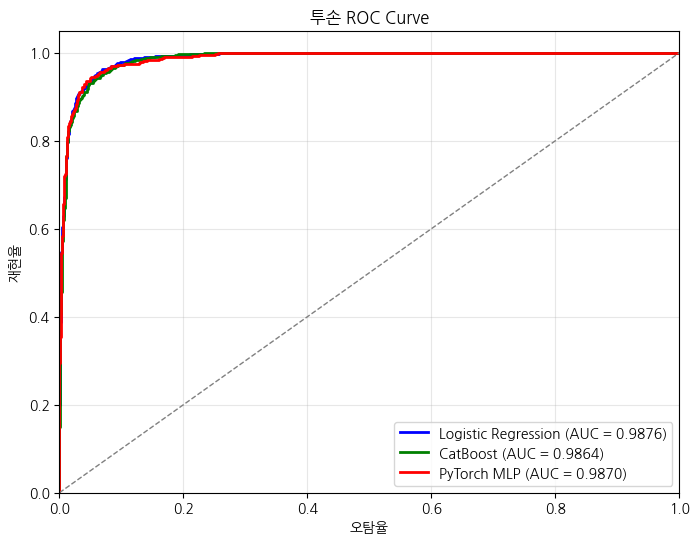

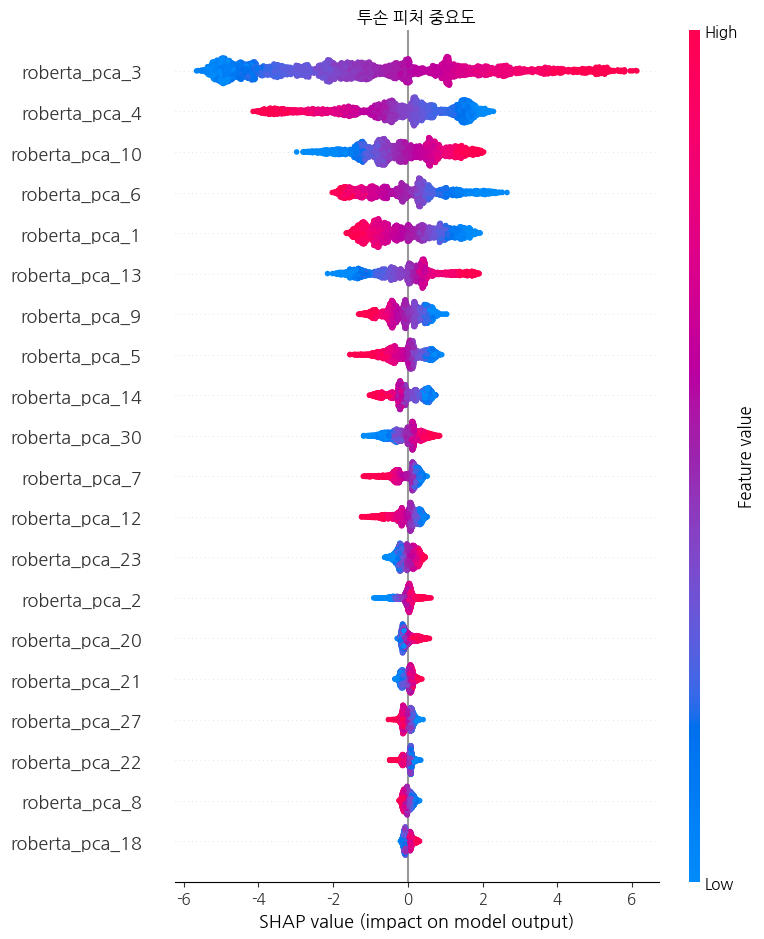

<Figure size 800x500 with 0 Axes>

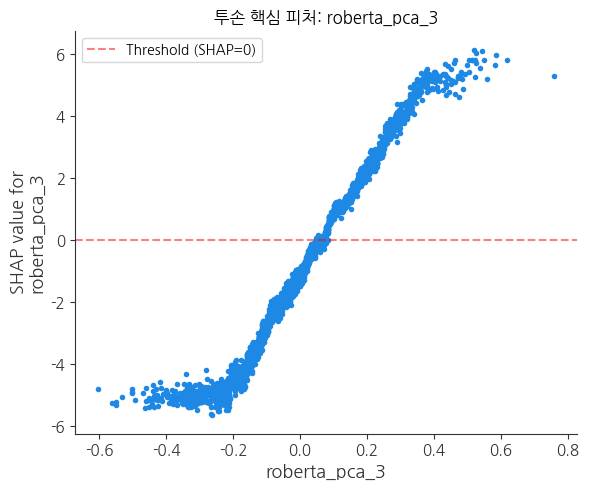

In [ ]:
# 투손입니다.

city = "Tucson"

X_train, X_test, y_train, y_test = city_datasets[city]
lr_probs = global_results[city]['lr_proba']
cb_probs = global_results[city]['cb_proba']
dl_probs = global_results[city]['dl_proba']

# 다중 모델 ROC Curve
plt.figure(figsize=(8, 6))
for name, probs, color in [("Logistic Regression", lr_probs, 'blue'),
                           ("CatBoost", cb_probs, 'green'),
                           ("PyTorch MLP", dl_probs, 'red')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('오탐율')
plt.ylabel('재현율')
plt.title('투손 ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("투손 피처 중요도")
plt.tight_layout()
plt.show()

# SHAP Dependence Plot
top_feature_idx = np.argmax(np.abs(shap_values).mean(axis=0))
top_feature_name = X_test.columns[top_feature_idx]

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature_idx, shap_values, X_test, interaction_index=None, show=False)
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Threshold (SHAP=0)')
plt.title(f"투손 핵심 피처: {top_feature_name}")
plt.legend()
plt.tight_layout()
plt.show()

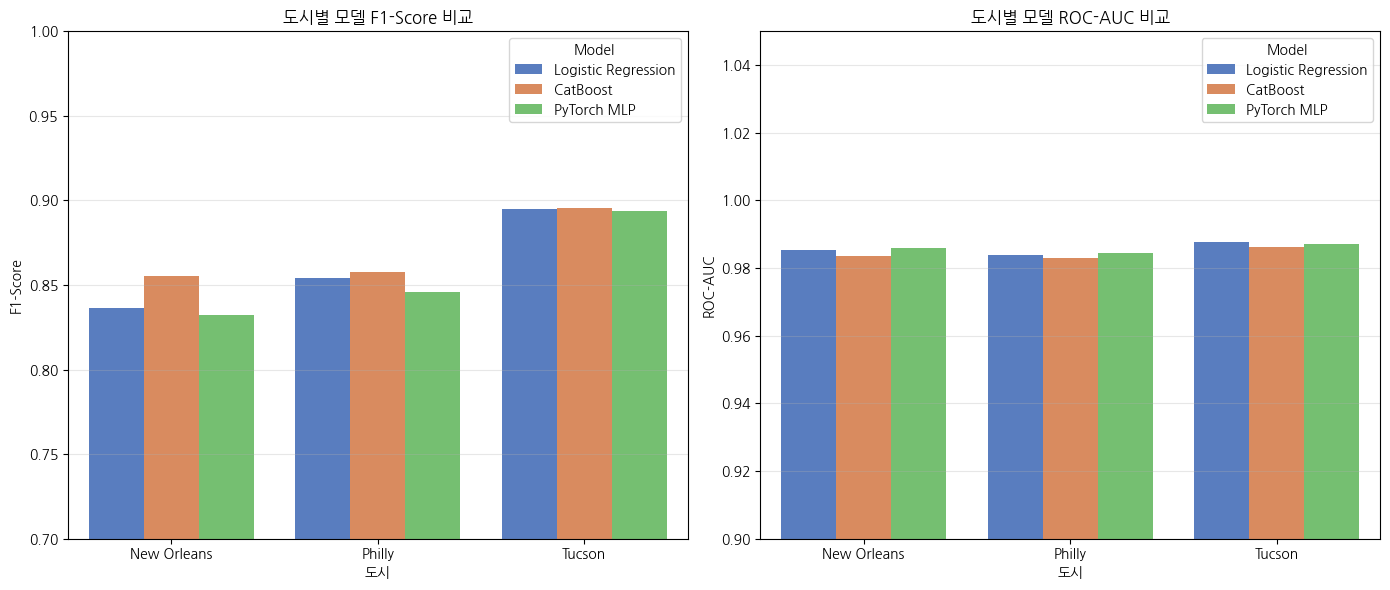

In [ ]:
# 3개 도시와 3가지 모델의 성능 지표(F1-Score, ROC-AUC)를 하나의 그래프로 통합하여 비교 분석하였습니다.
# 전역 딕셔너리에 저장된 예측 확률값을 활용하여 각 환경별 지표를 재산출하고, 이를 바 차트로 시각화하였습니다.

data_rows = []

for city in city_datasets.keys():
    _, _, _, y_test = city_datasets[city]

    # 저장된 확률값 불러오기
    lr_proba = global_results[city]['lr_proba']
    cb_proba = global_results[city]['cb_proba']
    dl_probs = global_results[city]['dl_proba']

    # 0.5 임계값 기준으로 이진 예측값 변환
    lr_pred = (lr_proba >= 0.5).astype(int)
    cb_pred = (cb_proba >= 0.5).astype(int)
    dl_pred = (dl_probs >= 0.5).astype(int)

    # 모델별 지표 계산 후 리스트에 저장
    for model_name, preds, probas in [("Logistic Regression", lr_pred, lr_proba),
                                      ("CatBoost", cb_pred, cb_proba),
                                      ("PyTorch MLP", dl_pred, dl_probs)]:
        f1 = f1_score(y_test, preds)
        auc_val = roc_auc_score(y_test, probas)
        data_rows.append({"City": city, "Model": model_name, "F1-Score": f1, "ROC-AUC": auc_val})

df_metrics = pd.DataFrame(data_rows)

# 시각화 수행 (F1-Score와 ROC-AUC 대조)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 도시별 F1-Score 비교 그래프
sns.barplot(x="City", y="F1-Score", hue="Model", data=df_metrics, ax=axes[0], palette="muted")
axes[0].set_title("도시별 모델 F1-Score 비교")
axes[0].set_ylim(0.7, 1.0)
axes[0].set_xlabel("도시")
axes[0].grid(axis='y', alpha=0.3)

# 도시별 ROC-AUC 비교 그래프
sns.barplot(x="City", y="ROC-AUC", hue="Model", data=df_metrics, ax=axes[1], palette="muted")
axes[1].set_title("도시별 모델 ROC-AUC 비교")
axes[1].set_ylim(0.9, 1.05)
axes[1].set_xlabel("도시")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

[New Orleans] 모델 오류 분석 결과


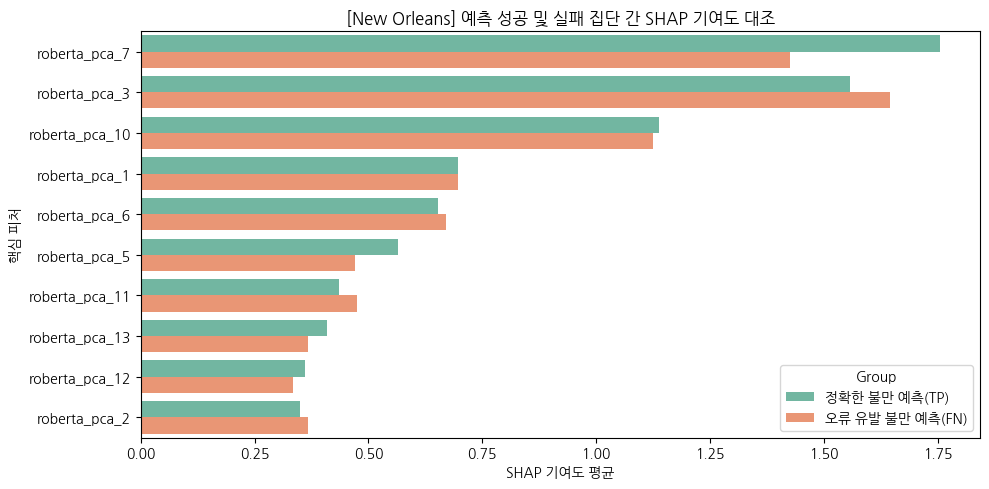

[Philly] 모델 오류 분석 결과


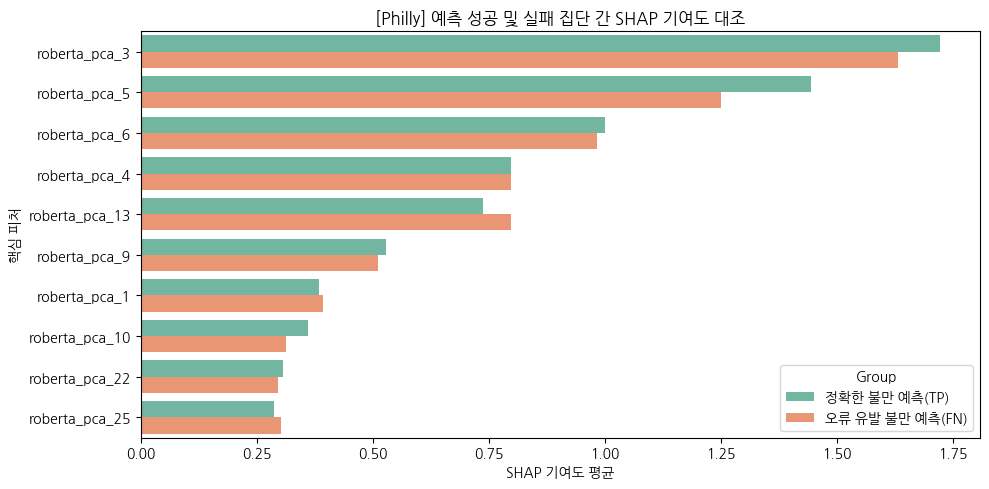

[Tucson] 모델 오류 분석 결과


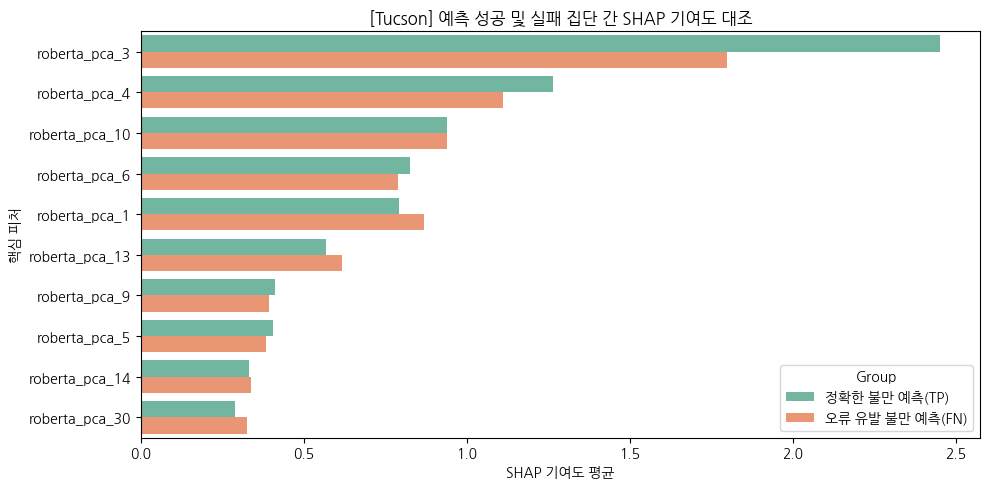

In [ ]:
# 모델이 예측에 실패한 원인을 규명하기 위해 도시별 오류 분석(Error Analysis)을 수행하였습니다.
# 정답을 맞춘 불만족 리뷰(True Positive)와 만족 리뷰로 오해한 불만족 리뷰(False Negative)의 SHAP 값을 대조하여 모델이 분류에 혼선을 겪은 요인을 추적하였습니다.

for city in city_datasets.keys():
    print(f"[{city}] 모델 오류 분석 결과")

    X_train, X_test, y_train, y_test = city_datasets[city]
    cb_model = global_results[city]['cb_model']
    cb_preds = cb_model.predict(X_test)

    # SHAP 값 호출
    explainer = shap.TreeExplainer(cb_model)
    shap_values = explainer.shap_values(X_test)

    # True Positive(성공)와 False Negative(실패) 인덱스 분리
    tp_idx = np.where((y_test == 1) & (cb_preds == 1))[0]
    fn_idx = np.where((y_test == 1) & (cb_preds == 0))[0]

    if len(fn_idx) > 0:
        # 각 그룹의 피처별 SHAP 절대값 평균 계산
        tp_shap_mean = np.abs(shap_values[tp_idx]).mean(axis=0)
        fn_shap_mean = np.abs(shap_values[fn_idx]).mean(axis=0)

        df_error = pd.DataFrame({
            'Feature': X_test.columns,
            '정확한 불만 예측(TP)': tp_shap_mean,
            '오류 유발 불만 예측(FN)': fn_shap_mean
        }).sort_values(by='정확한 불만 예측(TP)', ascending=False).head(10)

        # 데이터 구조 변환 후 시각화
        df_error_melt = df_error.melt(id_vars='Feature', var_name='Group', value_name='Mean SHAP')

        plt.figure(figsize=(10, 5))
        sns.barplot(x='Mean SHAP', y='Feature', hue='Group', data=df_error_melt, palette='Set2')
        plt.title(f"[{city}] 예측 성공 및 실패 집단 간 SHAP 기여도 대조")
        plt.xlabel("SHAP 기여도 평균")
        plt.ylabel("핵심 피처")
        plt.tight_layout()
        plt.show()